In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Loading Datset
df=pd.read_csv('breast-cancer-wisconsin-data_data.csv')
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


In [3]:
#Checking Info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [4]:
#Dropping Unwanted columns
df.drop(columns=['id','Unnamed: 32'],inplace=True)

In [5]:
#Checking Null Values
df.isnull().sum()

diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64

In [6]:
#Checking Duplicates
df.duplicated().sum()

np.int64(0)

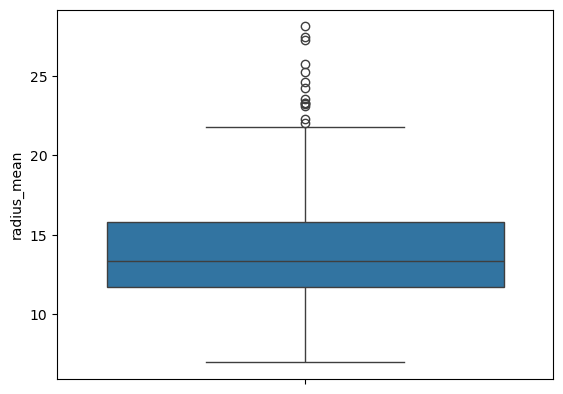

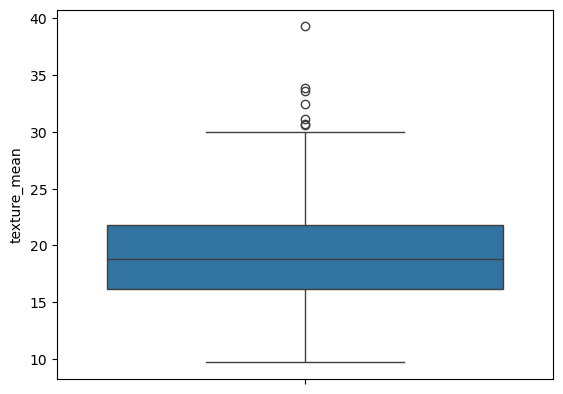

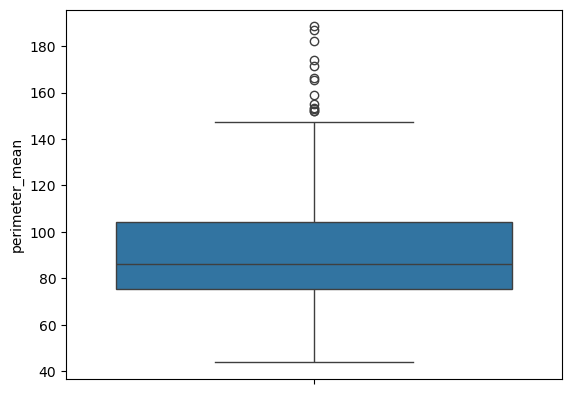

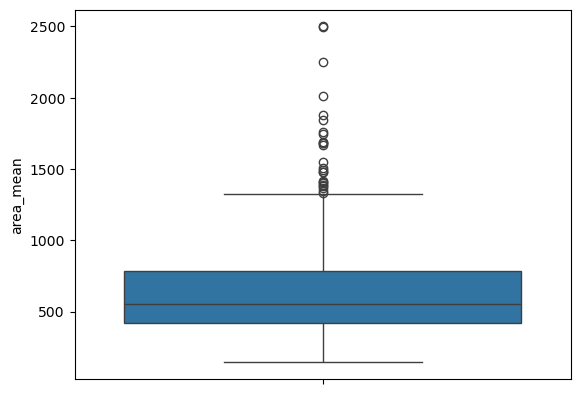

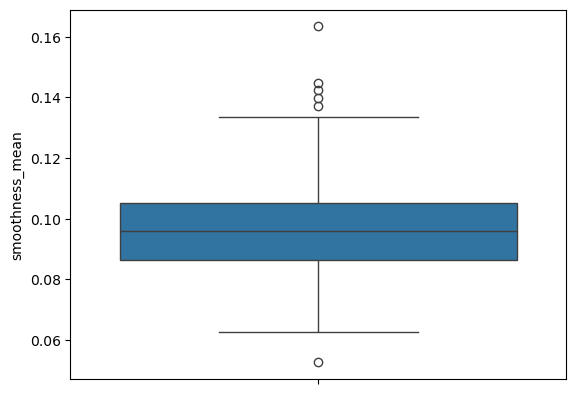

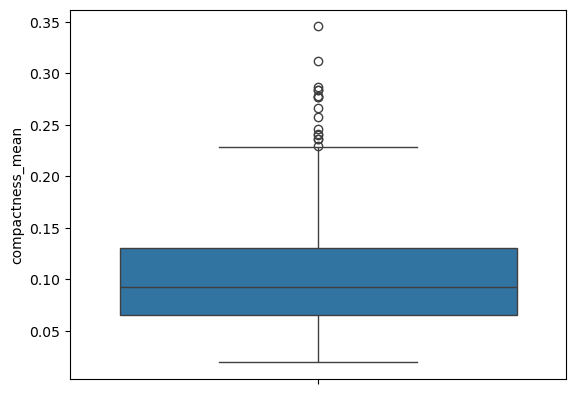

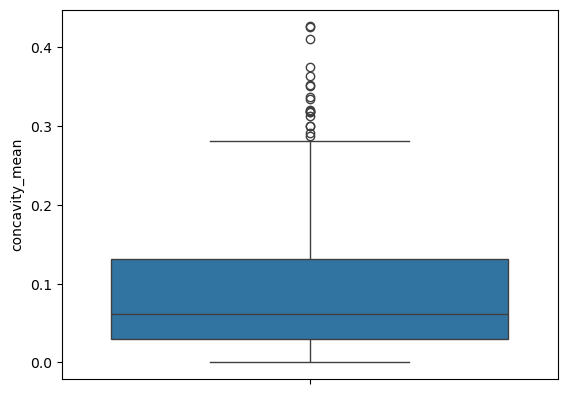

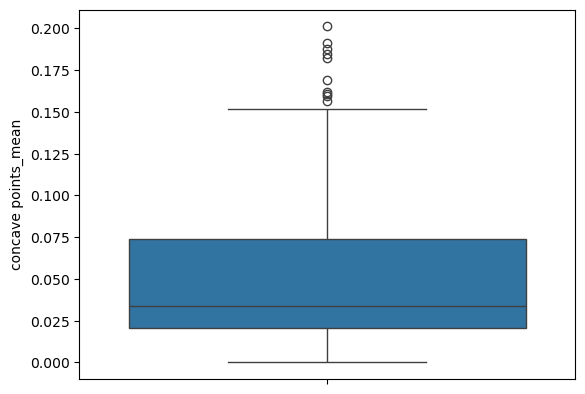

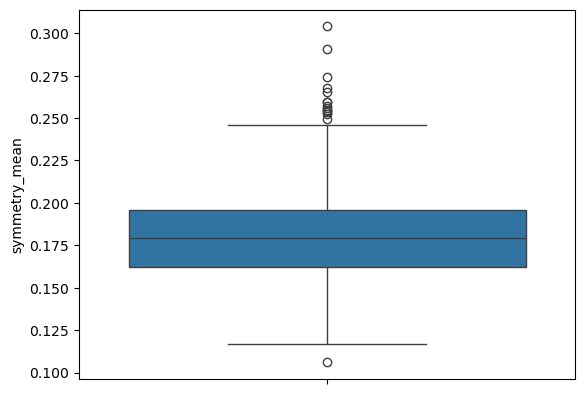

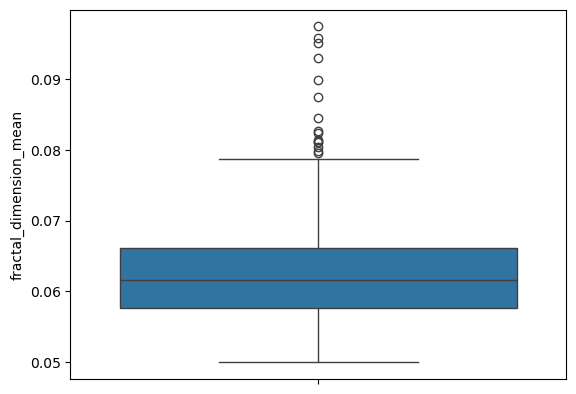

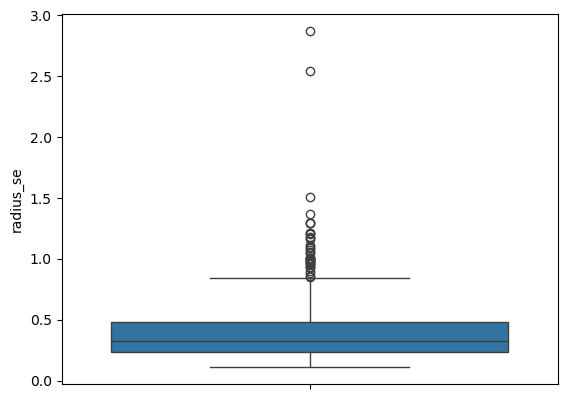

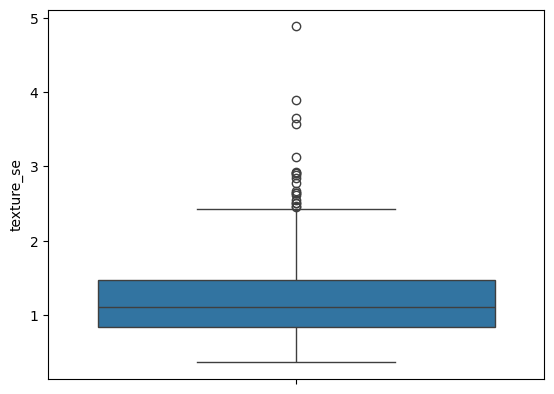

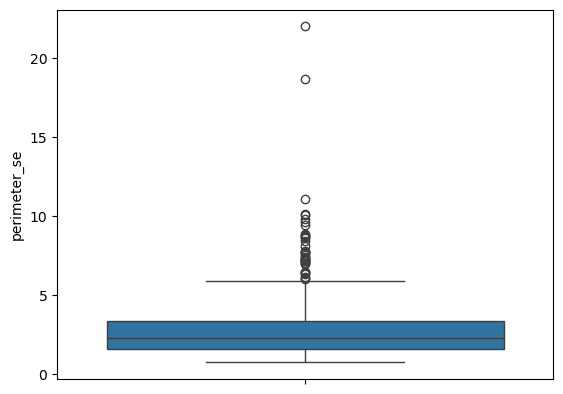

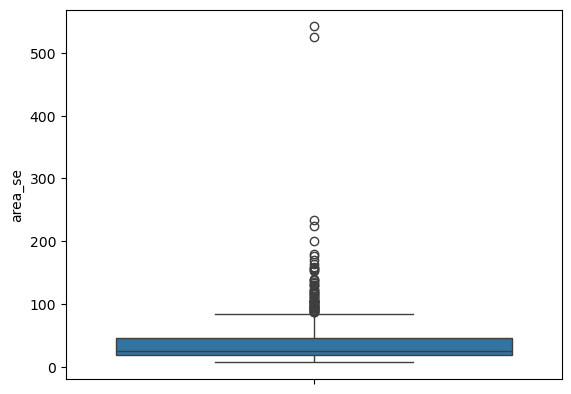

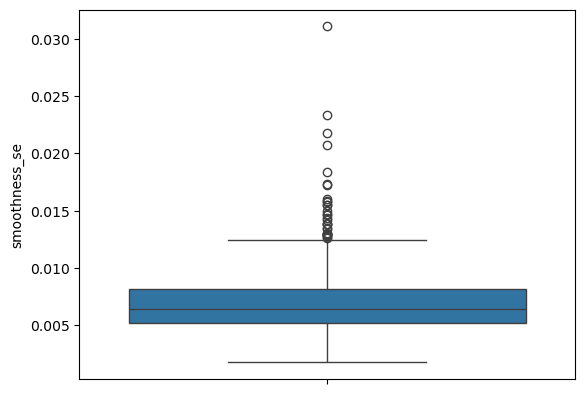

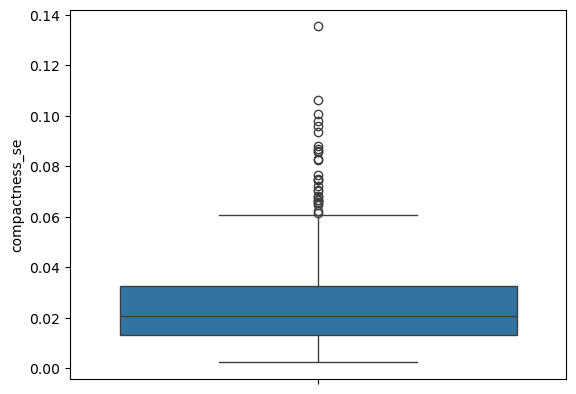

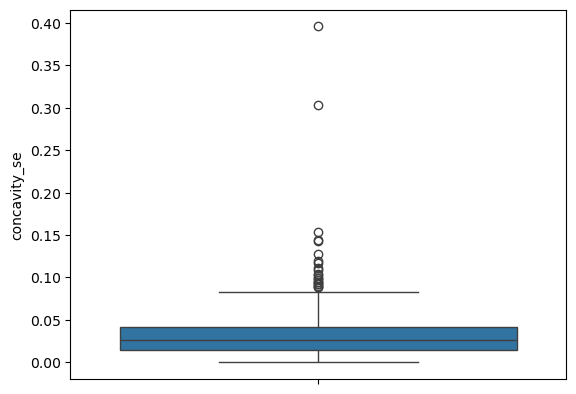

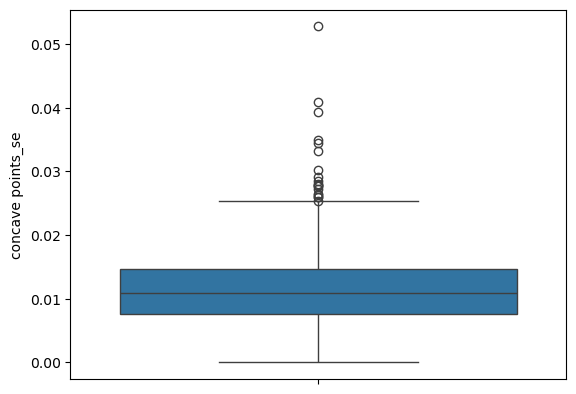

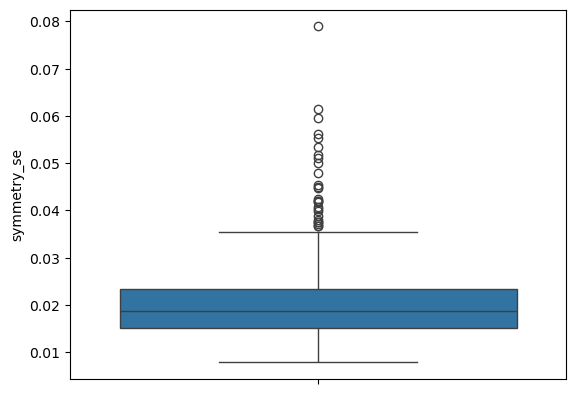

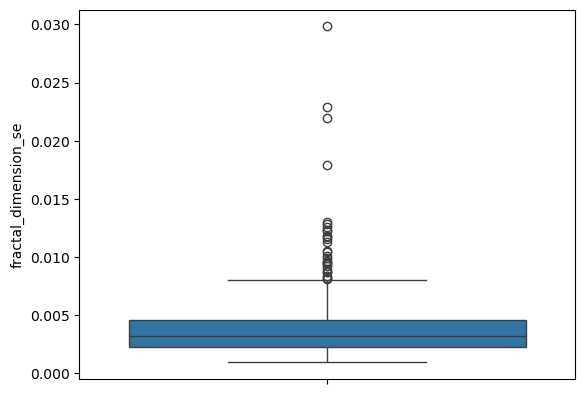

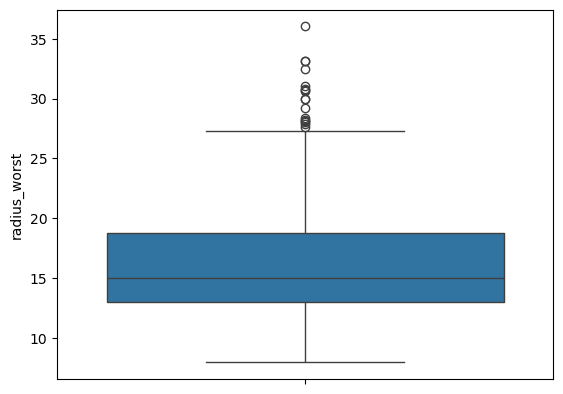

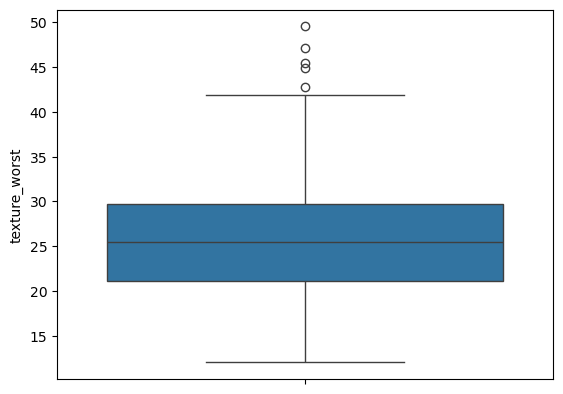

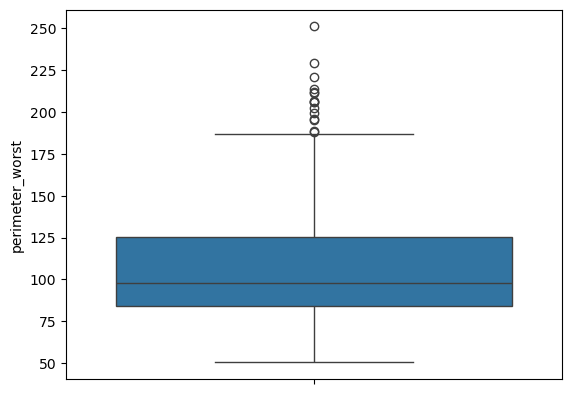

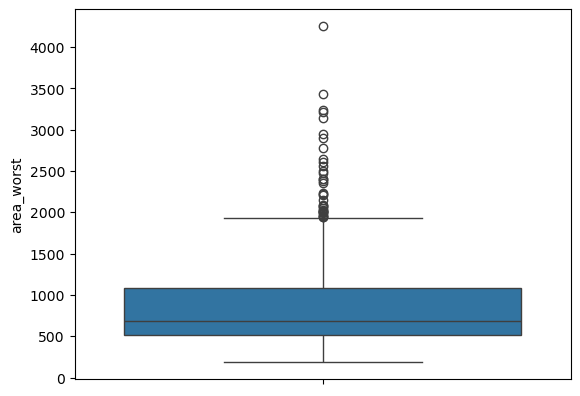

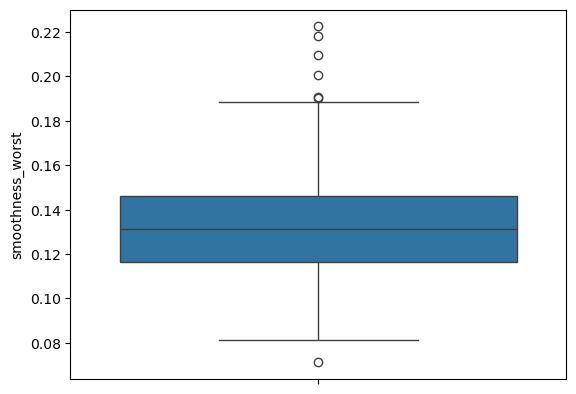

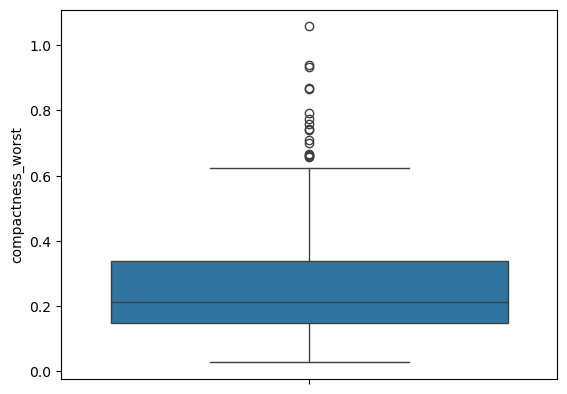

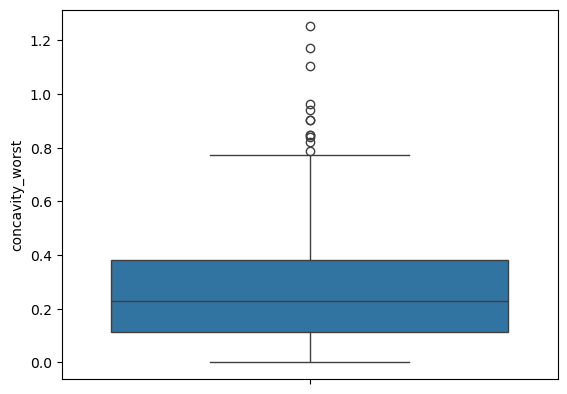

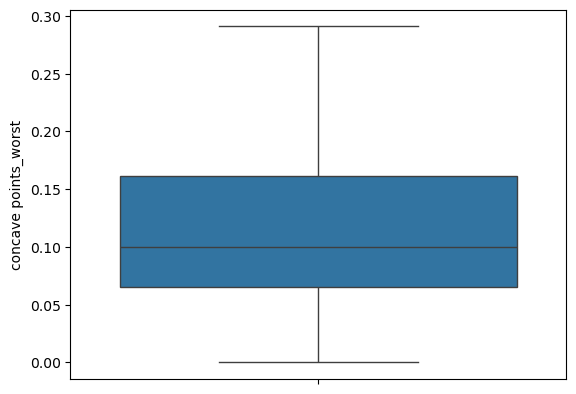

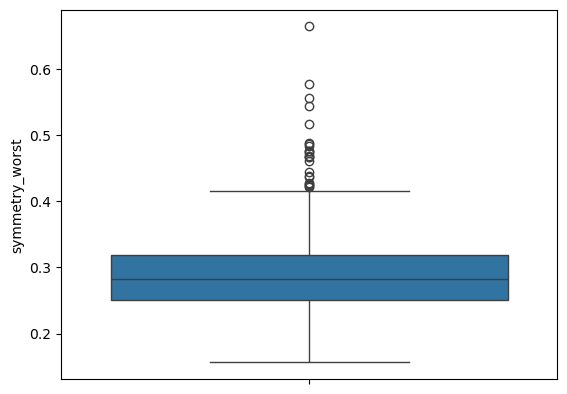

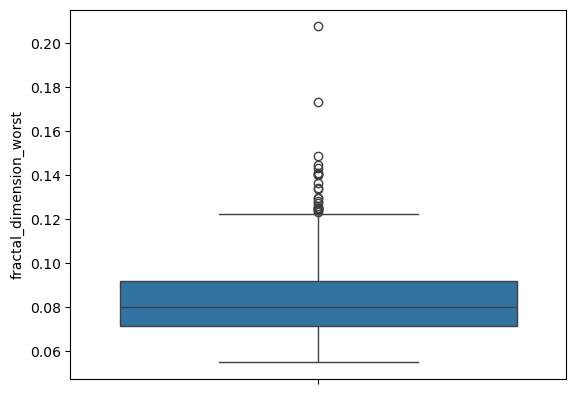

In [7]:
#Checking Outliers
import seaborn as sns
import matplotlib.pyplot as plt
#Checking Boxplots
for i in df.select_dtypes(include=['int','float']).columns:
    sns.boxplot(df[i])
    plt.show()

In [8]:
#Oiutlier capping
for i in df.select_dtypes(include=['int','float']).columns:
    q1=df[i].quantile(0.25)
    q3=df[i].quantile(0.75)
    IQR=q3-q1
    lower_bound=q1-1.5*IQR
    upper_bound=q3+1.5*IQR
    df[i]=df[i].clip(lower_bound,upper_bound)

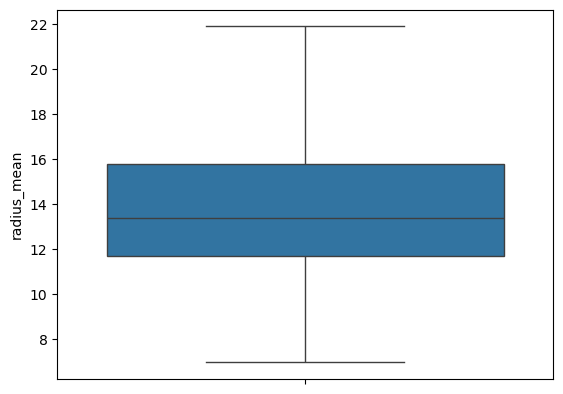

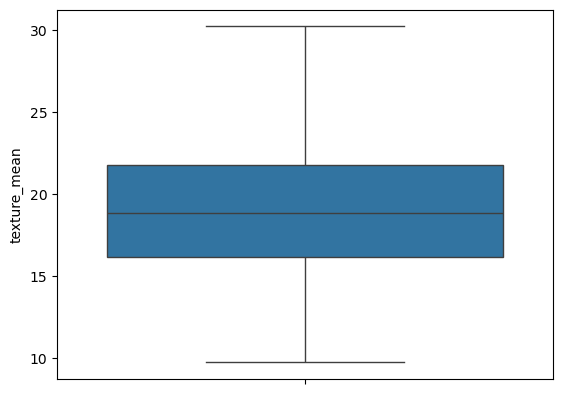

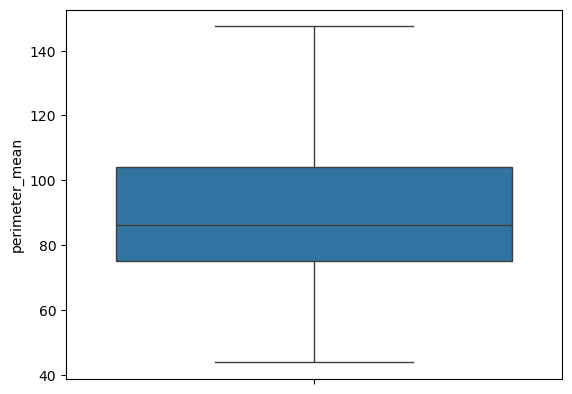

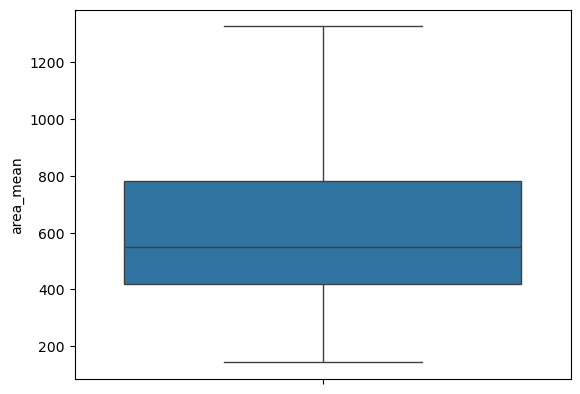

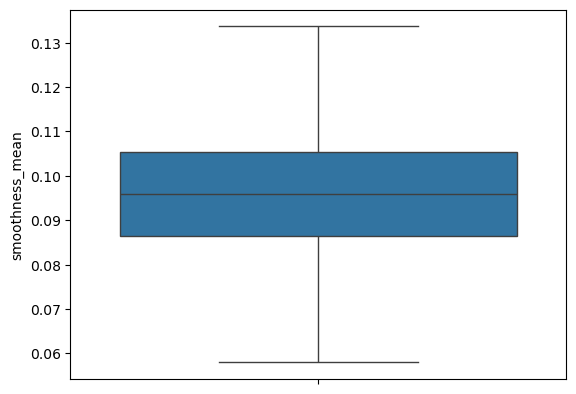

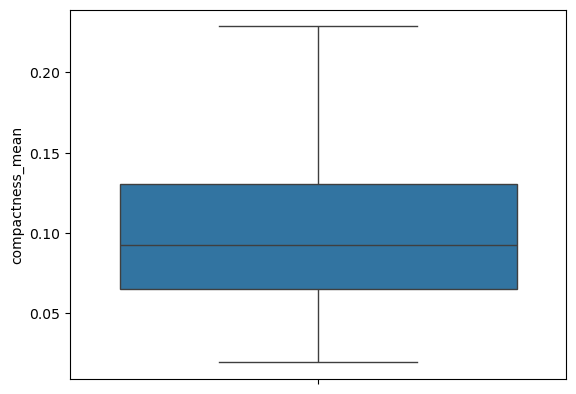

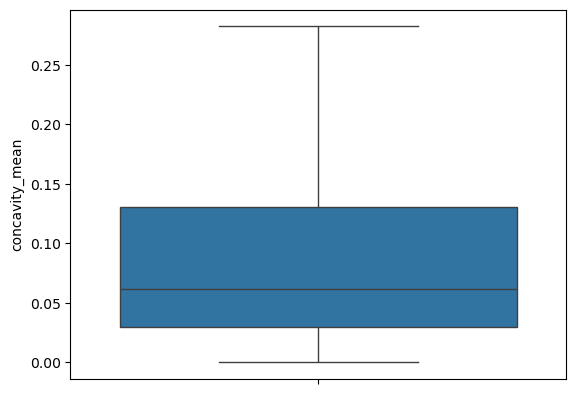

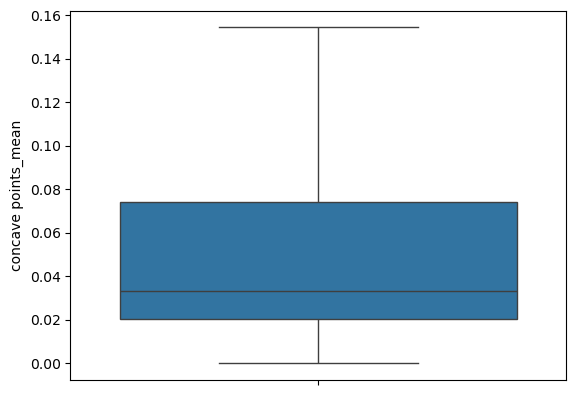

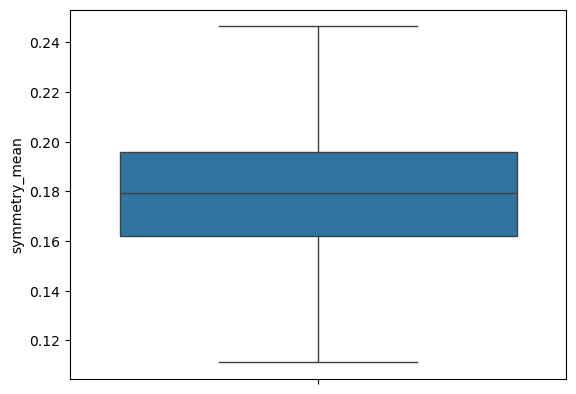

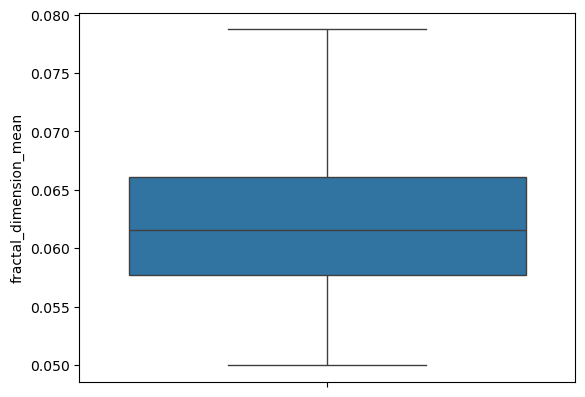

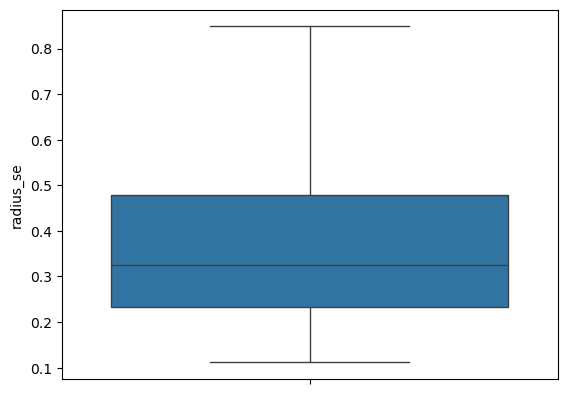

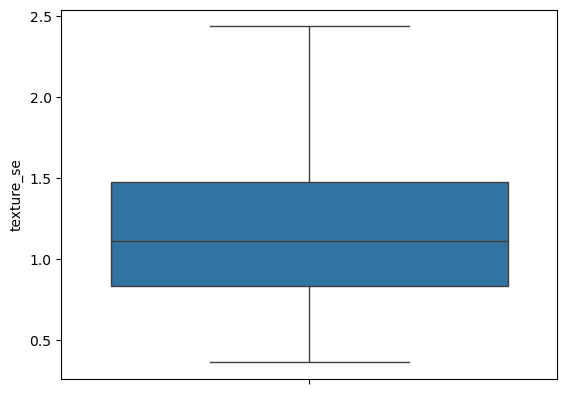

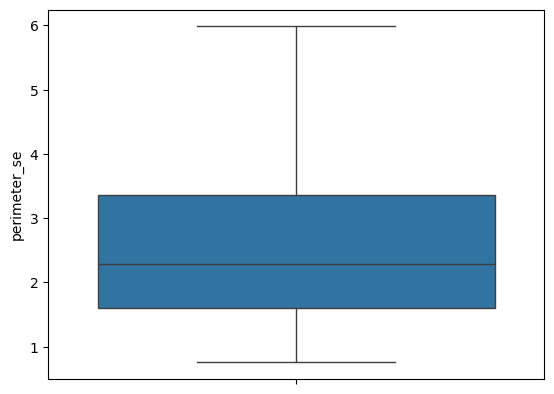

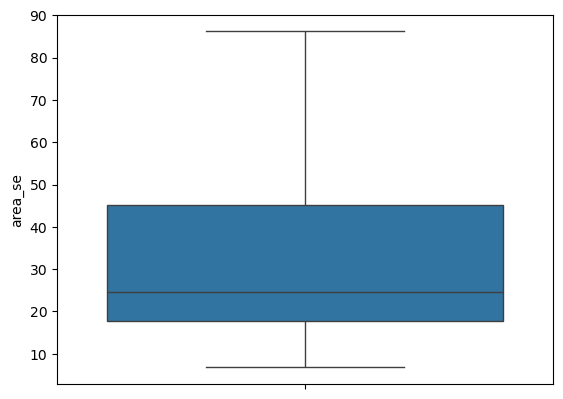

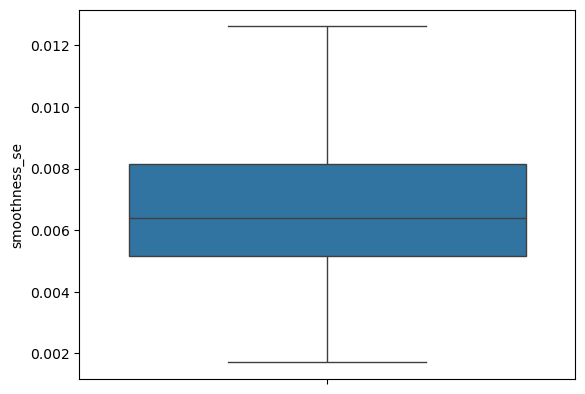

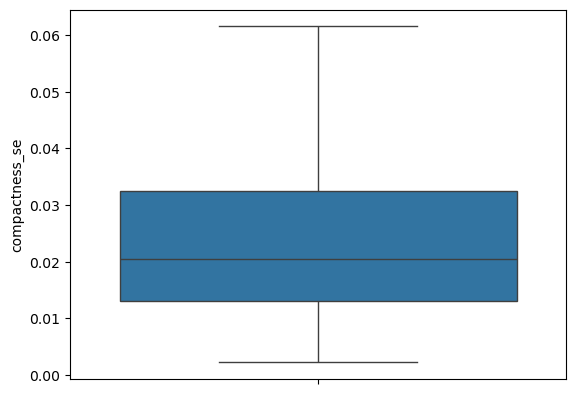

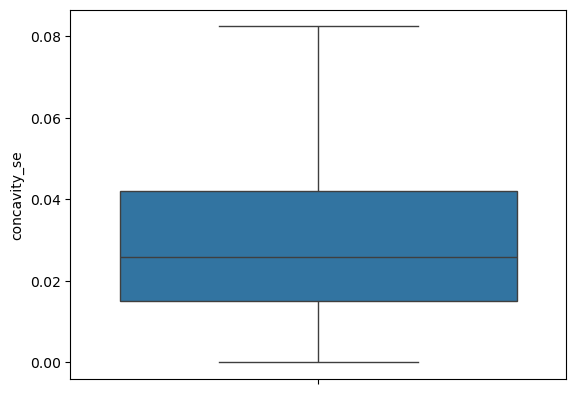

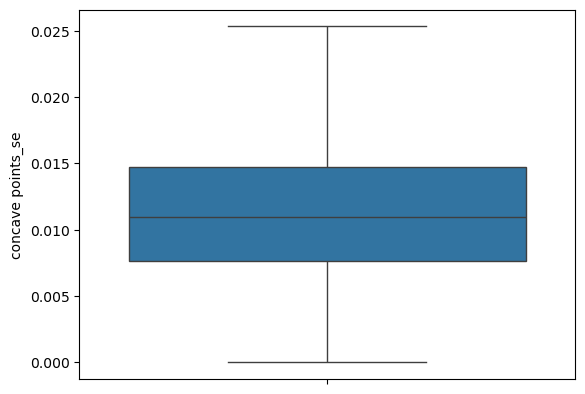

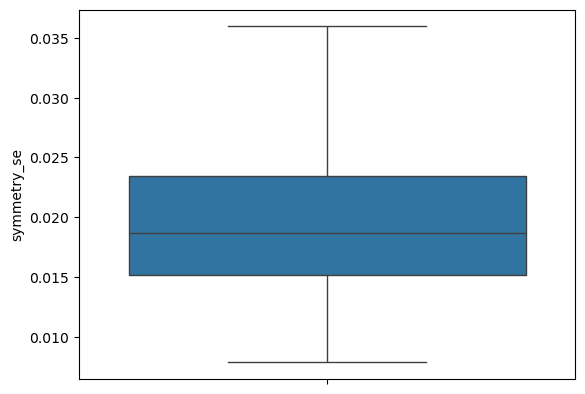

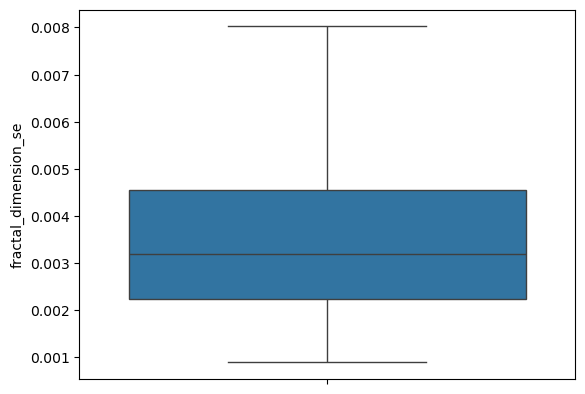

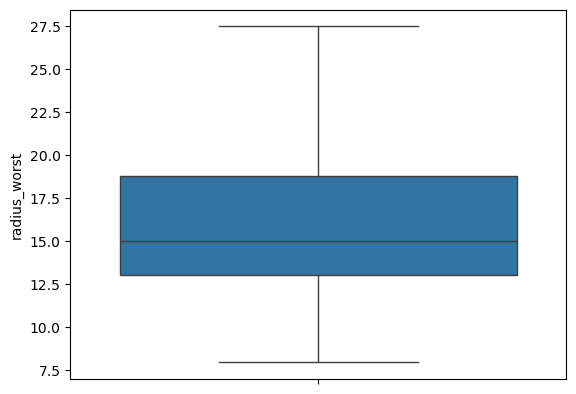

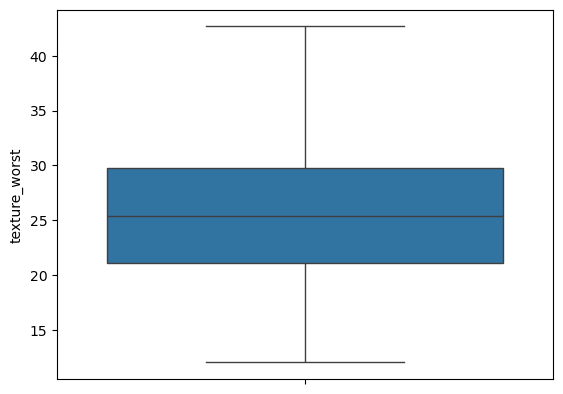

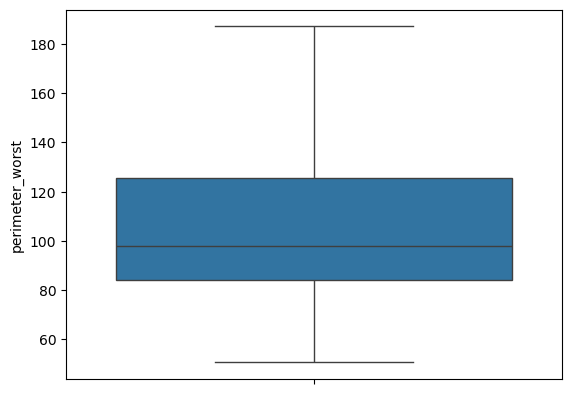

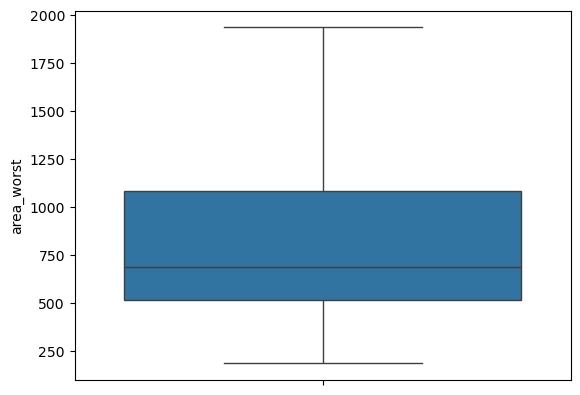

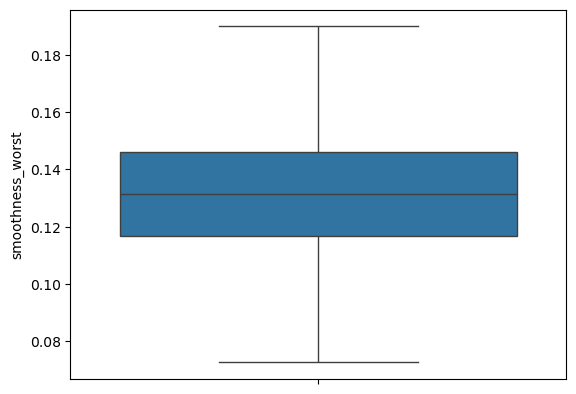

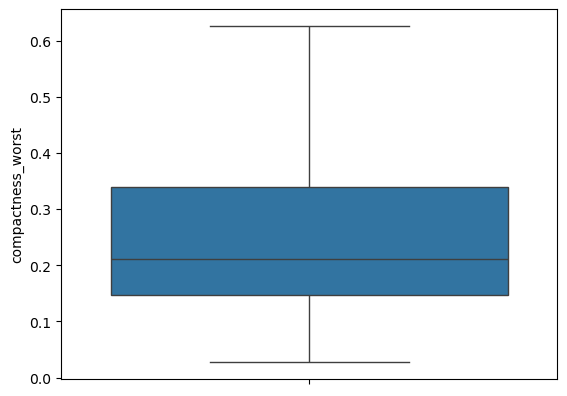

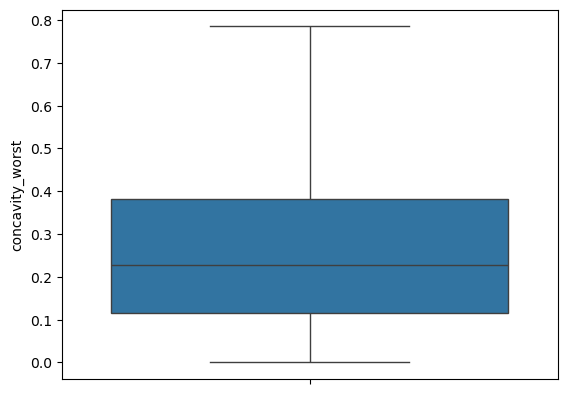

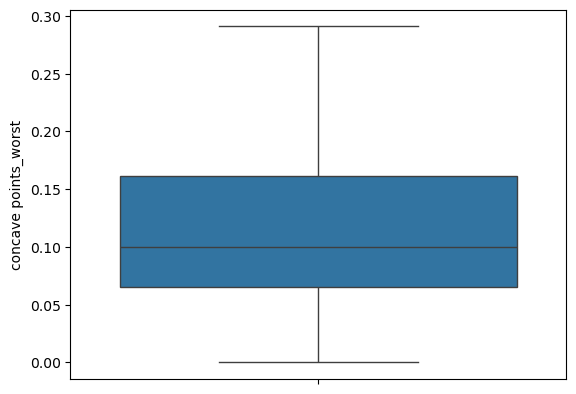

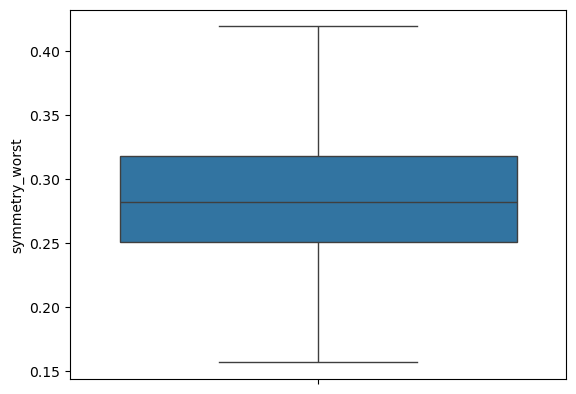

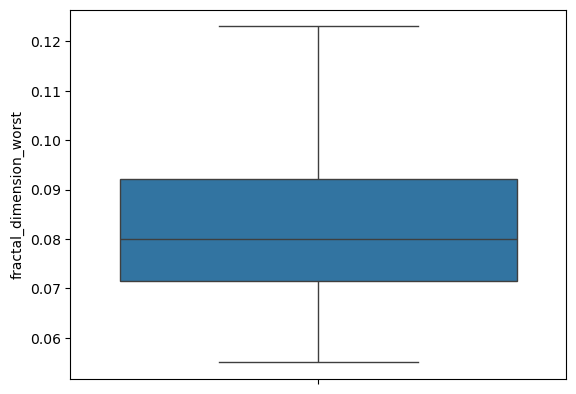

In [9]:
#Checking Outliers again after capping
for i in df.select_dtypes(include=['int','float']).columns:
    sns.boxplot(df[i])
    plt.show()

In [10]:
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.118400,0.22862,0.28241,0.14710,0.2419,...,25.380,17.33,184.60,1937.05,0.16220,0.62695,0.7119,0.2654,0.41915,0.11890
1,M,20.57,17.77,132.90,1326.0,0.084740,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1937.05,0.12380,0.18660,0.2416,0.1860,0.27500,0.08902
2,M,19.69,21.25,130.00,1203.0,0.109600,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.00,0.14440,0.42450,0.4504,0.2430,0.36130,0.08758
3,M,11.42,20.38,77.58,386.1,0.133695,0.22862,0.24140,0.10520,0.2464,...,14.910,26.50,98.87,567.70,0.19010,0.62695,0.6869,0.2575,0.41915,0.12301
4,M,20.29,14.34,135.10,1297.0,0.100300,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.00,0.13740,0.20500,0.4000,0.1625,0.23640,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,M,21.56,22.39,142.00,1326.3,0.111000,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,1937.05,0.14100,0.21130,0.4107,0.2216,0.20600,0.07115
565,M,20.13,28.25,131.20,1261.0,0.097800,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.00,0.11660,0.19220,0.3215,0.1628,0.25720,0.06637
566,M,16.60,28.08,108.30,858.1,0.084550,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.00,0.11390,0.30940,0.3403,0.1418,0.22180,0.07820
567,M,20.60,29.33,140.10,1265.0,0.117800,0.22862,0.28241,0.15200,0.2397,...,25.740,39.42,184.60,1821.00,0.16500,0.62695,0.7855,0.2650,0.40870,0.12301


In [11]:
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
df['diagnosis']=le.fit_transform(df['diagnosis'])
df

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,1,17.99,10.38,122.80,1001.0,0.118400,0.22862,0.28241,0.14710,0.2419,...,25.380,17.33,184.60,1937.05,0.16220,0.62695,0.7119,0.2654,0.41915,0.11890
1,1,20.57,17.77,132.90,1326.0,0.084740,0.07864,0.08690,0.07017,0.1812,...,24.990,23.41,158.80,1937.05,0.12380,0.18660,0.2416,0.1860,0.27500,0.08902
2,1,19.69,21.25,130.00,1203.0,0.109600,0.15990,0.19740,0.12790,0.2069,...,23.570,25.53,152.50,1709.00,0.14440,0.42450,0.4504,0.2430,0.36130,0.08758
3,1,11.42,20.38,77.58,386.1,0.133695,0.22862,0.24140,0.10520,0.2464,...,14.910,26.50,98.87,567.70,0.19010,0.62695,0.6869,0.2575,0.41915,0.12301
4,1,20.29,14.34,135.10,1297.0,0.100300,0.13280,0.19800,0.10430,0.1809,...,22.540,16.67,152.20,1575.00,0.13740,0.20500,0.4000,0.1625,0.23640,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,1,21.56,22.39,142.00,1326.3,0.111000,0.11590,0.24390,0.13890,0.1726,...,25.450,26.40,166.10,1937.05,0.14100,0.21130,0.4107,0.2216,0.20600,0.07115
565,1,20.13,28.25,131.20,1261.0,0.097800,0.10340,0.14400,0.09791,0.1752,...,23.690,38.25,155.00,1731.00,0.11660,0.19220,0.3215,0.1628,0.25720,0.06637
566,1,16.60,28.08,108.30,858.1,0.084550,0.10230,0.09251,0.05302,0.1590,...,18.980,34.12,126.70,1124.00,0.11390,0.30940,0.3403,0.1418,0.22180,0.07820
567,1,20.60,29.33,140.10,1265.0,0.117800,0.22862,0.28241,0.15200,0.2397,...,25.740,39.42,184.60,1821.00,0.16500,0.62695,0.7855,0.2650,0.40870,0.12301


<Axes: >

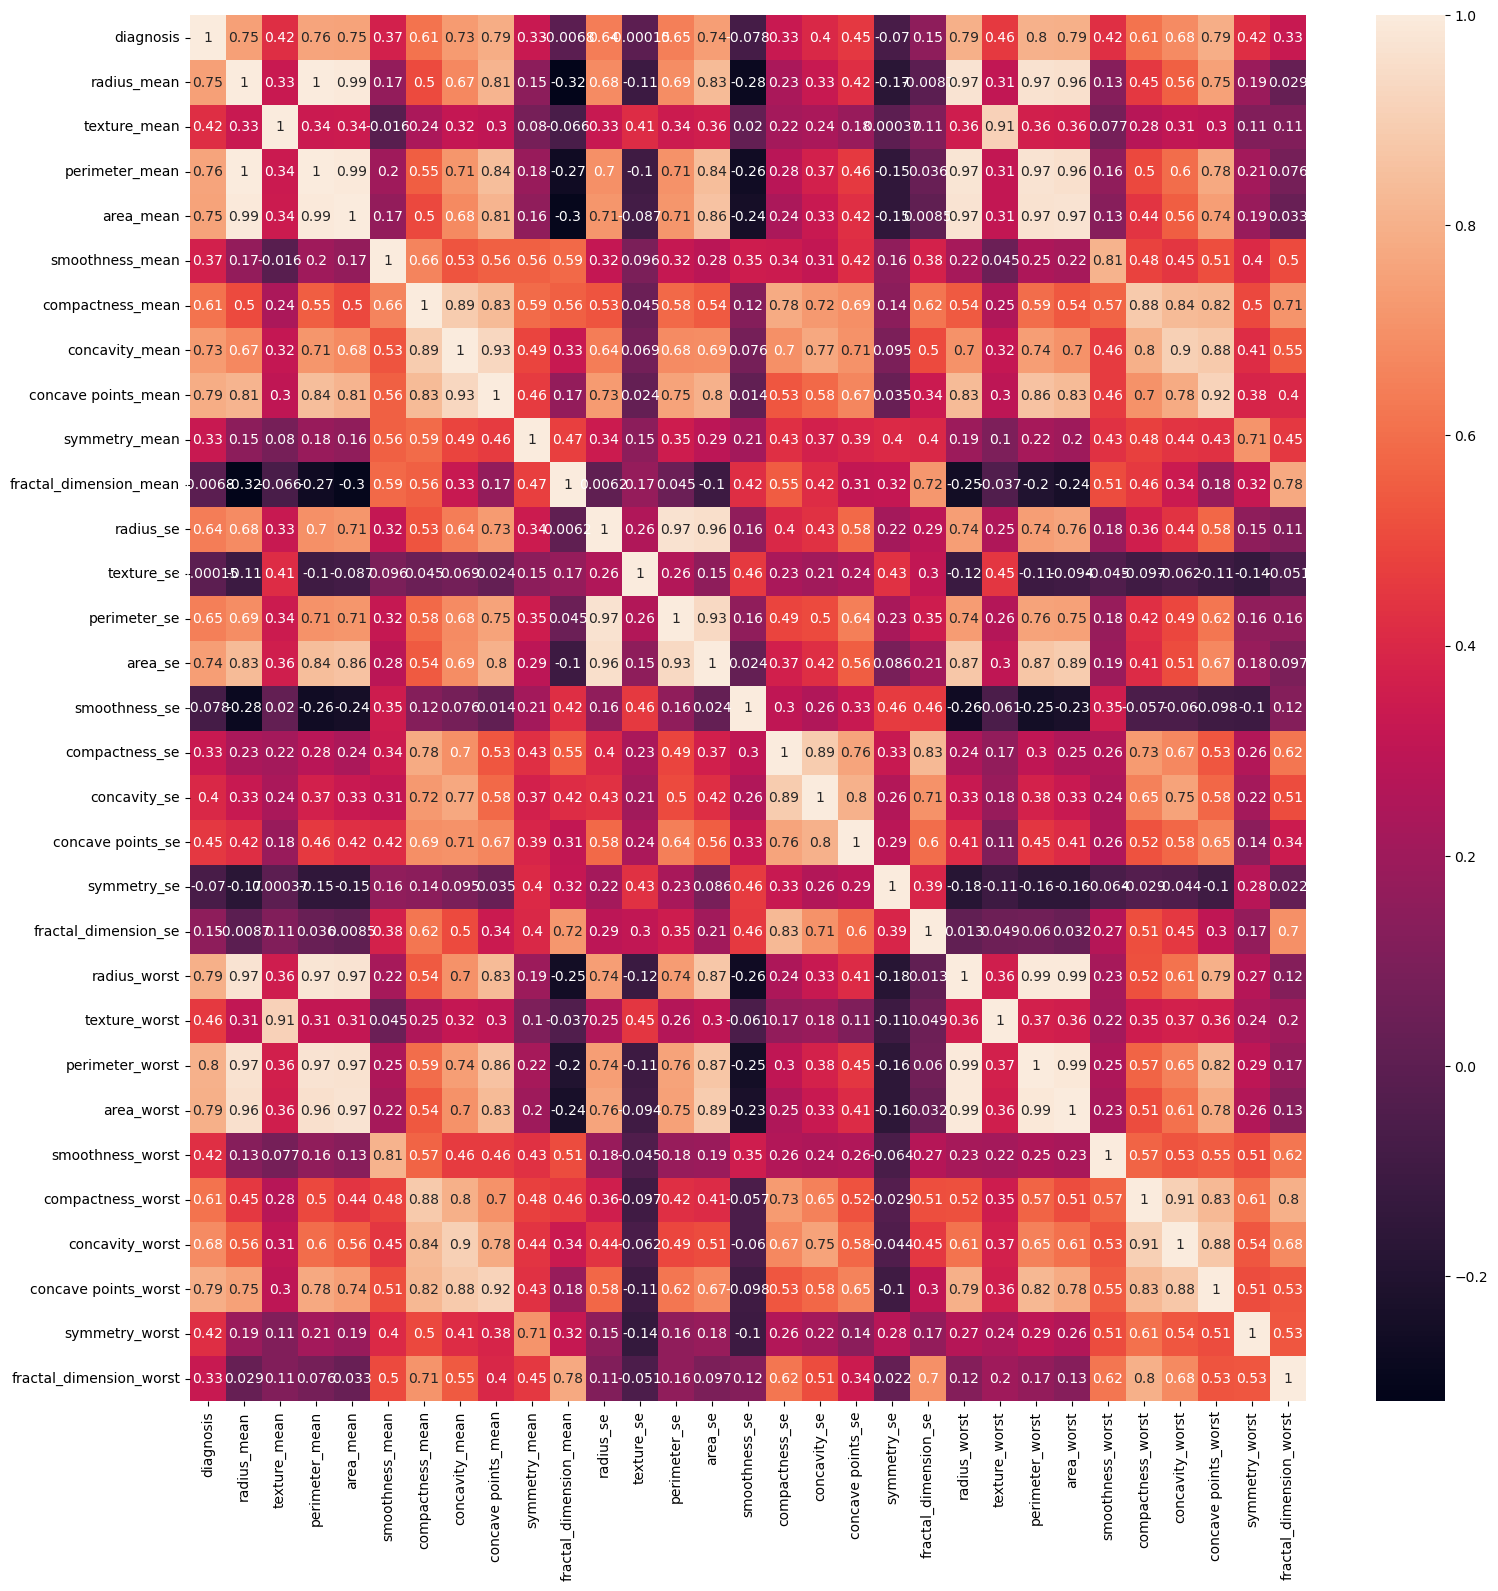

In [12]:
plt.figure(figsize=(18,18))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [13]:
feat= df.drop('diagnosis', axis=1)
tar = df['diagnosis']

In [22]:
f_classif(feat,tar)[0]

array([7.08155869e+02, 1.20826150e+02, 7.70546993e+02, 7.41521069e+02,
       8.82172335e+01, 3.33379255e+02, 6.36243499e+02, 9.29435001e+02,
       7.14519719e+01, 2.62293311e-02, 3.98395472e+02, 1.31805143e-05,
       4.07975475e+02, 6.82507418e+02, 3.45249722e+00, 7.01615863e+01,
       1.06796321e+02, 1.44078756e+02, 2.76046794e+00, 1.37848740e+01,
       9.66829905e+02, 1.50226883e+02, 1.01233837e+03, 9.71473689e+02,
       1.23839161e+02, 3.37915688e+02, 4.97312375e+02, 9.64385393e+02,
       1.20780848e+02, 6.86904334e+01])

In [24]:
pd.Series(f_classif(feat,tar)[0],index=feat.columns)

radius_mean                 708.155869
texture_mean                120.826150
perimeter_mean              770.546993
area_mean                   741.521069
smoothness_mean              88.217234
compactness_mean            333.379255
concavity_mean              636.243499
concave points_mean         929.435001
symmetry_mean                71.451972
fractal_dimension_mean        0.026229
radius_se                   398.395472
texture_se                    0.000013
perimeter_se                407.975475
area_se                     682.507418
smoothness_se                 3.452497
compactness_se               70.161586
concavity_se                106.796321
concave points_se           144.078756
symmetry_se                   2.760468
fractal_dimension_se         13.784874
radius_worst                966.829905
texture_worst               150.226883
perimeter_worst            1012.338365
area_worst                  971.473689
smoothness_worst            123.839161
compactness_worst        

In [26]:
pd.Series(f_classif(feat,tar)[0],index=feat.columns).sort_values(ascending=False)

perimeter_worst            1012.338365
area_worst                  971.473689
radius_worst                966.829905
concave points_worst        964.385393
concave points_mean         929.435001
perimeter_mean              770.546993
area_mean                   741.521069
radius_mean                 708.155869
area_se                     682.507418
concavity_mean              636.243499
concavity_worst             497.312375
perimeter_se                407.975475
radius_se                   398.395472
compactness_worst           337.915688
compactness_mean            333.379255
texture_worst               150.226883
concave points_se           144.078756
smoothness_worst            123.839161
texture_mean                120.826150
symmetry_worst              120.780848
concavity_se                106.796321
smoothness_mean              88.217234
symmetry_mean                71.451972
compactness_se               70.161586
fractal_dimension_worst      68.690433
fractal_dimension_se     

<Axes: >

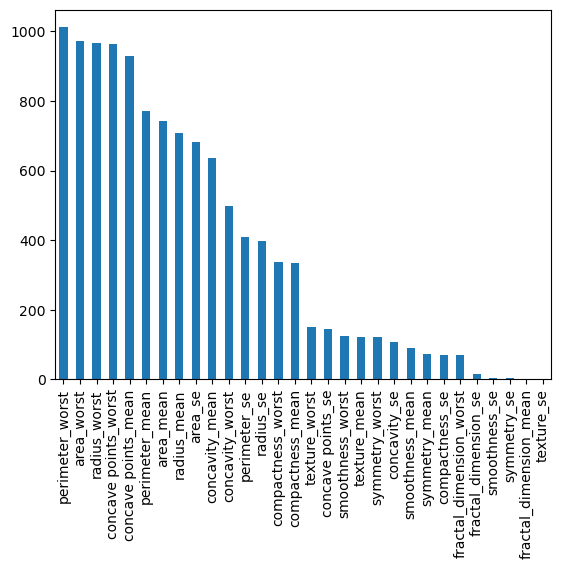

In [14]:
from sklearn.feature_selection import f_classif
pd.Series(f_classif(feat,tar)[0],index=feat.columns).sort_values(ascending=False).plot(kind='bar')

In [15]:
#Selecting best 10 columns
from sklearn.feature_selection import f_classif

scores = pd.DataFrame(
    f_classif(feat, tar)[0],
    index=feat.columns,
    columns=['F_score']
)

scores.sort_values(by='F_score', ascending=False).head(10).index

Index(['perimeter_worst', 'area_worst', 'radius_worst', 'concave points_worst',
       'concave points_mean', 'perimeter_mean', 'area_mean', 'radius_mean',
       'area_se', 'concavity_mean'],
      dtype='object')

In [16]:
x=df[['perimeter_worst', 'area_worst', 'radius_worst', 'concave points_worst',
       'concave points_mean', 'perimeter_mean', 'area_mean', 'radius_mean',
       'area_se', 'concavity_mean']]
y=df['diagnosis']

In [17]:
x

,perimeter_worst,area_worst,radius_worst,concave points_worst,concave points_mean,perimeter_mean,area_mean,radius_mean,area_se,concavity_mean
0,184.60,1937.05,25.380,0.2654,0.14710,122.80,1001.0,17.99,86.20,0.28241
1,158.80,1937.05,24.990,0.1860,0.07017,132.90,1326.0,20.57,74.08,0.08690
2,152.50,1709.00,23.570,0.2430,0.12790,130.00,1203.0,19.69,86.20,0.19740
3,98.87,567.70,14.910,0.2575,0.10520,77.58,386.1,11.42,27.23,0.24140
4,152.20,1575.00,22.540,0.1625,0.10430,135.10,1297.0,20.29,86.20,0.19800
...,...,...,...,...,...,...,...,...,...,...
564,166.10,1937.05,25.450,0.2216,0.13890,142.00,1326.3,21.56,86.20,0.24390
565,155.00,1731.00,23.690,0.1628,0.09791,131.20,1261.0,20.13,86.20,0.14400
566,126.70,1124.00,18.980,0.1418,0.05302,108.30,858.1,16.60,48.55,0.09251
567,184.60,1821.00,25.740,0.2650,0.15200,140.10,1265.0,20.60,86.20,0.28241


In [18]:
y

0      1
1      1
2      1
3      1
4      1
      ..
564    1
565    1
566    1
567    1
568    0
Name: diagnosis, Length: 569, dtype: int64

In [27]:
#Train test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=50,stratify=df['diagnosis'])

In [29]:
#Building Model
from sklearn.linear_model import LogisticRegression
lr=LogisticRegression()
lr.fit(x_train,y_train)
pred_train=lr.predict(x_train)
pred_test=lr.predict(x_test)
from sklearn.metrics import *
print("Train Acc is ",accuracy_score(y_train,pred_train))
print(classification_report(y_train,pred_train))
print("Test Acc is ",accuracy_score(y_test,pred_test))
print(classification_report(y_test,pred_test))

Train Acc is  0.9460093896713615
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       267
           1       0.94      0.91      0.93       159

    accuracy                           0.95       426
   macro avg       0.95      0.94      0.94       426
weighted avg       0.95      0.95      0.95       426

Test Acc is  0.9440559440559441
              precision    recall  f1-score   support

           0       0.95      0.97      0.96        90
           1       0.94      0.91      0.92        53

    accuracy                           0.94       143
   macro avg       0.94      0.94      0.94       143
weighted avg       0.94      0.94      0.94       143



C:\Users\harsh\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [30]:
#Building Model
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()
dt.fit(x_train,y_train)
pred=dt.predict(x_train)
pred
from sklearn.metrics import *
print("Train Acc is ",accuracy_score(y_train,pred_train))
print(classification_report(y_train,pred_train))
print("Test Acc is ",accuracy_score(y_test,pred_test))
print(classification_report(y_test,pred_test))

Train Acc is  0.9460093896713615
              precision    recall  f1-score   support

           0       0.95      0.97      0.96       267
           1       0.94      0.91      0.93       159

    accuracy                           0.95       426
   macro avg       0.95      0.94      0.94       426
weighted avg       0.95      0.95      0.95       426

Test Acc is  0.9440559440559441
              precision    recall  f1-score   support

           0       0.95      0.97      0.96        90
           1       0.94      0.91      0.92        53

    accuracy                           0.94       143
   macro avg       0.94      0.94      0.94       143
weighted avg       0.94      0.94      0.94       143



In [31]:
#Applying Scaler & Training Model
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

sc = StandardScaler()

# Fit scaler only on training data, then transform
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

lr1 = LogisticRegression()
lr1.fit(x_train_scaled, y_train)
pred_train = lr1.predict(x_train_scaled)
pred_test = lr1.predict(x_test_scaled)

print("Train Acc is ",accuracy_score(y_train,pred_train))
print(classification_report(y_train,pred_train))
print("Test Acc is ",accuracy_score(y_test,pred_test))
print(classification_report(y_test,pred_test))

Train Acc is  0.9530516431924883
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       267
           1       0.95      0.92      0.94       159

    accuracy                           0.95       426
   macro avg       0.95      0.95      0.95       426
weighted avg       0.95      0.95      0.95       426

Test Acc is  0.965034965034965
              precision    recall  f1-score   support

           0       0.96      0.99      0.97        90
           1       0.98      0.92      0.95        53

    accuracy                           0.97       143
   macro avg       0.97      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143



In [ ]:
x_train.columns

In [32]:
import joblib
joblib.dump(lr1, "model.pkl")

['model.pkl']

In [33]:
# Save scaler
joblib.dump(sc, "scaler.pkl")

['scaler.pkl']

In [ ]:
x_train

In [ ]:
y_train

In [ ]:
pd.concat([x_train, y_train], axis=1)

In [34]:
lr1.predict([[1,2,3,4,5,6,7,8,9,10]])

array([1])

In [35]:
x_train

,perimeter_worst,area_worst,radius_worst,concave points_worst,concave points_mean,perimeter_mean,area_mean,radius_mean,area_se,concavity_mean
354,79.62,453.5,12.12,0.03922,0.014710,71.24,384.6,11.140,28.84,0.04505
555,69.57,357.6,10.84,0.09127,0.027380,65.67,321.4,10.290,14.46,0.05999
467,71.11,380.2,11.15,0.02500,0.005769,61.06,286.3,9.668,20.98,0.01479
8,106.20,739.3,15.49,0.20600,0.093530,87.50,519.8,13.000,24.32,0.18590
551,77.80,436.6,12.02,0.06413,0.022570,71.49,378.4,11.130,17.85,0.04824
...,...,...,...,...,...,...,...,...,...,...
125,100.30,725.9,15.49,0.05104,0.011410,88.44,588.7,13.850,17.91,0.01420
79,91.88,622.1,14.24,0.07926,0.023150,83.19,506.3,12.860,20.35,0.03889
560,100.20,706.7,15.30,0.10480,0.043040,91.38,600.4,14.050,29.84,0.04462
514,113.80,967.0,17.58,0.11200,0.043350,97.26,701.9,15.050,38.49,0.07486


In [36]:
y_train

354    0
555    0
467    0
8      1
551    0
      ..
125    0
79     0
560    0
514    1
213    1
Name: diagnosis, Length: 426, dtype: int64